# Tutorial 01: Linear Regression & Gradient Descent From Scratch

### Learning Objectives
1. Understand the Linear Hypothesis $\hat{y} = Xw + b$ and the Mean Squared Error (MSE) objective.
2. Mathematically derive the exact vectorized gradients $\nabla_w J$ and $\nabla_b J$.
3. Train `GradientDescentLinearRegression` on synthetic 1D data and observe convergence.
4. Compare first-order Gradient Descent against the closed-form Normal Equations.
5. Solve 3 practical exercises exploring learning rates, normalization, and mini-batches.

---
## 1. Mathematical Foundations

### The Linear Hypothesis
For a dataset with $N$ observations and $D$ features:
$$\hat{y} = Xw + b \mathbf{1}_N$$
where $X \in \mathbb{R}^{N \times D}$, $w \in \mathbb{R}^D$, $b \in \mathbb{R}$, and $\hat{y} \in \mathbb{R}^N$.

### Mean Squared Error (MSE)
$$J(w, b) = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 = \frac{1}{N} \|\hat{y} - y\|_2^2$$

### Vectorized Gradients
Let residual error vector $e = \hat{y} - y \in \mathbb{R}^N$:
$$\nabla_w J = \frac{2}{N} X^T e = \frac{2}{N} X^T (\hat{y} - y)$$
$$\nabla_b J = \frac{2}{N} \sum_{i=1}^N (\hat{y}_i - y_i) = 2 \cdot \text{mean}(\hat{y} - y)$$

### Parameter Updates
$$w^{(t+1)} = w^{(t)} - \eta \nabla_w J, \quad b^{(t+1)} = b^{(t)} - \eta \nabla_b J$$

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.linear_regression import GradientDescentLinearRegression, compute_mse, compute_r2
from src.solvers import ClosedFormLinearRegression

## 2. Generating Synthetic 1D Data
We generate $N=100$ samples with ground truth slope $w = 3.5$, intercept $b = 1.2$, and Gaussian noise $\epsilon \sim \mathcal{N}(0, 0.5^2)$.

In [2]:
np.random.seed(42)
N = 100
X_1d = np.random.uniform(-3, 3, size=(N, 1))
true_w = 3.5
true_b = 1.2
noise = np.random.normal(0, 0.5, size=N)
y_1d = (X_1d[:, 0] * true_w) + true_b + noise

print(f"Dataset generated: N={N}, X shape={X_1d.shape}, y shape={y_1d.shape}")
print(f"Ground Truth: w={true_w}, b={true_b}")

Dataset generated: N=100, X shape=(100, 1), y shape=(100,)
Ground Truth: w=3.5, b=1.2


## 3. Training Gradient Descent & Tracking Loss
We instantiate `GradientDescentLinearRegression` with learning rate $\eta = 0.05$ and train for $200$ epochs.

In [3]:
gd_model = GradientDescentLinearRegression(lr=0.05, n_iters=200, optimizer="sgd")
gd_model.fit(X_1d, y_1d)

y_pred_gd = gd_model.predict(X_1d)
r2_gd = gd_model.score(X_1d, y_1d)
mse_gd = compute_mse(y_1d, y_pred_gd)

print(f"Fitted Parameters: w={gd_model.weights[0]:.4f}, b={gd_model.bias:.4f}")
print(f"Metrics: R2={r2_gd:.4f}, MSE={mse_gd:.4f}")
print(f"Epochs trained: {len(gd_model.loss_history_)}")

Fitted Parameters: w=3.4617, b=1.1926
Metrics: R2=0.9947, MSE=0.2016
Epochs trained: 200


## 4. Comparing GD vs. Analytical Closed-Form
We fit `ClosedFormLinearRegression(method="normal")` on the exact same data to verify analytical equivalence.

In [4]:
cf_model = ClosedFormLinearRegression(method="normal_equation")
cf_model.fit(X_1d, y_1d)

print(f"Closed-Form Normal Equations: w={cf_model.weights[0]:.4f}, b={cf_model.bias:.4f}")
print(f"Weight difference (GD vs CF): {abs(gd_model.weights[0] - cf_model.weights[0]):.6f}")
print(f"Bias difference (GD vs CF):   {abs(gd_model.bias - cf_model.bias):.6f}")

Closed-Form Normal Equations: w=3.4617, b=1.1926
Weight difference (GD vs CF): 0.000000
Bias difference (GD vs CF):   0.000000


## 5. Visualizing the Fitted Line & Loss Convergence

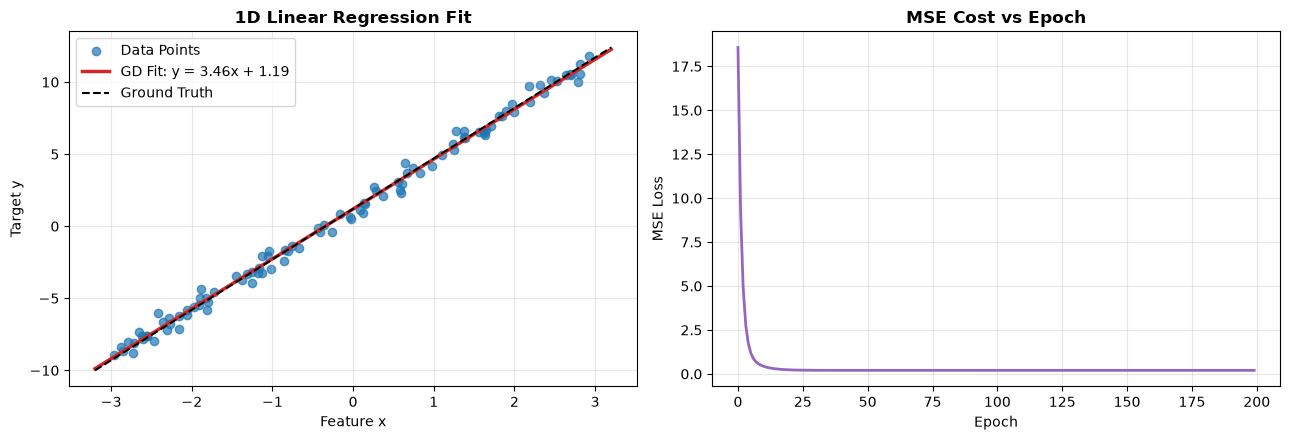

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Fitted Line
x_line = np.linspace(-3.2, 3.2, 100).reshape(-1, 1)
y_line_gd = gd_model.predict(x_line)

axes[0].scatter(X_1d, y_1d, alpha=0.7, color="tab:blue", label="Data Points")
axes[0].plot(x_line, y_line_gd, color="tab:red", lw=2.5, label=f"GD Fit: y = {gd_model.weights[0]:.2f}x + {gd_model.bias:.2f}")
axes[0].plot(x_line, x_line[:, 0] * true_w + true_b, color="black", linestyle="--", lw=1.5, label="Ground Truth")
axes[0].set_title("1D Linear Regression Fit", fontweight="bold")
axes[0].set_xlabel("Feature x")
axes[0].set_ylabel("Target y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss Convergence Curve
axes[1].plot(gd_model.loss_history_, color="tab:purple", lw=2)
axes[1].set_title("MSE Cost vs Epoch", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Exploring Learning Rate Sensitivity
Try learning rates $\eta \in [0.001, 0.05, 1.2]$. What happens to the loss curve when $\eta$ is too small vs too large?

<details>
<summary><b>Click to View Solution</b></summary>

```python
for test_lr in [0.001, 0.05, 0.9]:
    m = GradientDescentLinearRegression(lr=test_lr, n_iters=100)
    m.fit(X_1d, y_1d)
    print(f"lr={test_lr:<6} -> Final Loss: {m.loss_history_[-1]:.4f} | w: {m.weights[0]:.3f}")
# lr=0.001 converges very slowly; lr=0.05 converges smoothly; lr >= 1.0 oscillates or diverges!
```
</details>

### Exercise 2: Adding Multiple Input Features
Generate 2D synthetic data $y = 1.5 x_1 - 2.0 x_2 + 0.5 + \epsilon$ and fit `GradientDescentLinearRegression`. Verify that recovered weights match.

<details>
<summary><b>Click to View Solution</b></summary>

```python
X_2d = np.random.randn(200, 2)
y_2d = 1.5 * X_2d[:, 0] - 2.0 * X_2d[:, 1] + 0.5 + np.random.normal(0, 0.1, 200)
m_2d = GradientDescentLinearRegression(lr=0.1, n_iters=200).fit(X_2d, y_2d)
print("Recovered weights:", np.round(m_2d.weights, 3), "Bias:", round(m_2d.bias, 3))
```
</details>